# Post-processing

An optimiser returns *continuous* weights — fractions of capital. To trade them you need whole
shares, and to communicate them you need a report. Post-processing covers both: turning weights
into an integer share count under a cash budget, and visualising the result. For the full
treatment see the
[post-processing examples](../examples/6_post_processing/01_Finite_Allocation.md).

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res = optimise(MeanRisk(; obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

## 1. Finite allocation

Finite allocation converts the continuous weights into integer share counts you can actually
buy, given the latest prices and a cash budget. `GreedyAllocation` is the solver-free
option: it rounds to whole shares and spends the leftover cash on the largest underweights. The
call takes the weights, the price vector, and the available cash.

In [2]:
prices = vec(values(X)[end, :])
cash = 100_000.0
alloc = optimise(GreedyAllocation(),
                 FiniteAllocationInput(; w = res.w, prices = prices, cash = cash))

GreedyAllocationResult
       oe ┼ DataType: DataType
  retcode ┼ OptimisationSuccess
          │   res ┴ nothing
   shares ┼ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
     cost ┼ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
        w ┼ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
     cash ┼ Float64: 14.222999999965346
       fb ┴ nothing


The result carries the integer `shares`, the per-asset `cost`, the *realised* weights `w` (after
rounding), and the leftover `cash`. The realised weights track the target closely, and only a
few dollars are left uninvested.

In [3]:
invested = sum(alloc.shares .* prices)
pretty_table(DataFrame("Asset" => rd.nx, "Target weight" => res.w,
                       "Shares" => round.(Int, alloc.shares), "Realised weight" => alloc.w);
             formatters = [resfmt],
             title = "Discrete allocation of \$$(round(Int, cash)) — invested \$$(round(Int, invested)), cash left \$$(round(alloc.cash, digits = 2))")

Discrete allocation of $100000 — invested $99986, cash left $14.22
┌────────┬───────────────┬────────┬─────────────────┐
│  Asset │ Target weight │ Shares │ Realised weight │
│ String │       Float64 │  Int64 │         Float64 │
├────────┼───────────────┼────────┼─────────────────┤
│   AAPL │         0.0 % │      0 │           0.0 % │
│    AMD │         0.0 % │      0 │           0.0 % │
│    BAC │         0.0 % │      0 │           0.0 % │
│    BBY │         0.0 % │      0 │           0.0 % │
│    CVX │       7.432 % │     43 │         7.471 % │
│     GE │       0.806 % │     13 │         0.831 % │
│     HD │         0.0 % │      0 │           0.0 % │
│    JNJ │      36.974 % │    212 │        36.911 % │
│    JPM │       0.749 % │      6 │         0.778 % │
│     KO │      11.161 % │    178 │        11.146 % │
│    LLY │         0.0 % │      0 │           0.0 % │
│    MRK │      17.467 % │    159 │        17.426 % │
│   MSFT │         0.0 % │      0 │           0.0 % │
│    PEP │     

For an *exact* (rather than greedy) allocation, `DiscreteAllocation` solves a
mixed-integer program — pass it a MIP-capable `Solver`. It is more precise but needs a
MIP solver; the greedy method needs none. See
[Finite Allocation](../examples/6_post_processing/01_Finite_Allocation.md).

## 2. Reporting

The plotting functions used throughout this guide are the reporting toolkit:
`plot_stacked_bar_composition` for weights, `plot_measures` for
risk/return scatters and frontiers, `plot_risk_contribution` for where the risk sits,
and `plot_prior` for the input moments. Here is the realised portfolio's composition.

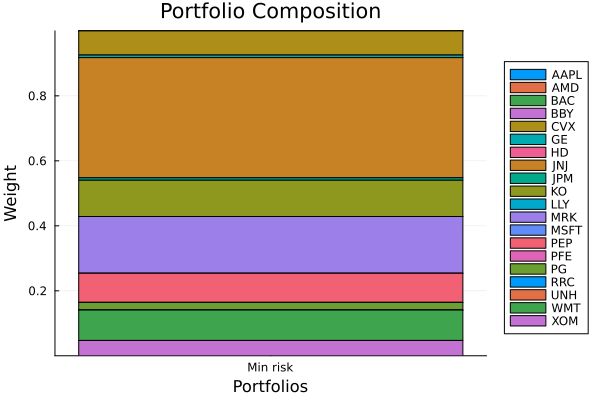

In [4]:
plot_stacked_bar_composition([res], rd; xticks = (1:1, ["Min risk"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*